# Tokenization and batching

A language model never receives raw text. It receives integer IDs arranged into tensors. This notebook makes that translation visible by comparing character, word, and subword-like tokenization, then building padded batches and masks.

## Question

What information is gained or lost when the same sentence is represented with different vocabularies? How do padding, truncation, and batch dimensions change the prediction problem?

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F

SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
text = "the model reads one token at a time"
character_tokens = list(text)
word_tokens = text.split()
subword_tokens = ["the", " model", " reads", " one", " token", " at", " a", " time"]
for name, tokens in [("characters",character_tokens),("words",word_tokens),("subword-like",subword_tokens)]:
    print(f"{name:14} {len(tokens):2} tokens:", tokens)

characters     35 tokens: ['t', 'h', 'e', ' ', 'm', 'o', 'd', 'e', 'l', ' ', 'r', 'e', 'a', 'd', 's', ' ', 'o', 'n', 'e', ' ', 't', 'o', 'k', 'e', 'n', ' ', 'a', 't', ' ', 'a', ' ', 't', 'i', 'm', 'e']
words           8 tokens: ['the', 'model', 'reads', 'one', 'token', 'at', 'a', 'time']
subword-like    8 tokens: ['the', ' model', ' reads', ' one', ' token', ' at', ' a', ' time']


A tokenizer is a vocabulary plus two operations: encode text into IDs and decode IDs back into text. Unknown and special tokens are explicit design choices.

In [3]:
vocabulary = ["<pad>", "<unk>", "the", " model", " reads", " one", " token", " at", " a", " time"]
token_to_id = {token:i for i,token in enumerate(vocabulary)}

def encode(tokens):
    return [token_to_id.get(token, token_to_id["<unk>"]) for token in tokens]

def decode(ids):
    return "".join(vocabulary[index] for index in ids if vocabulary[index] != "<pad>")

ids = encode(subword_tokens)
print(ids)
print(decode(ids))

[2, 3, 4, 5, 6, 7, 8, 9]
the model reads one token at a time


## Contexts, targets, and padding

For next-token prediction, a sequence is shifted by one position: the input contains tokens 0 through *T−1*, while the target contains tokens 1 through *T*. Padding exists only to make examples in one batch the same length; a mask tells the loss which positions are real.

In [4]:
sequences = [
    encode(["the", " model", " reads", " one", " token"]),
    encode(["the", " model", " reads"]),
    encode(["the", " model", " reads", " one", " token", " at", " a", " time"]),
]
pad_id = token_to_id["<pad>"]
max_length = max(map(len, sequences))
inputs = torch.tensor([sequence[:-1] + [pad_id] * (max_length-len(sequence)) for sequence in sequences])
targets = torch.tensor([sequence[1:] + [pad_id] * (max_length-len(sequence)) for sequence in sequences])
valid_mask = targets != pad_id
print("inputs shape:", tuple(inputs.shape))
print("targets shape:", tuple(targets.shape))
print("valid positions:\n", valid_mask)

inputs shape: (3, 7)
targets shape: (3, 7)
valid positions:
 tensor([[ True,  True,  True,  True, False, False, False],
        [ True,  True, False, False, False, False, False],
        [ True,  True,  True,  True,  True,  True,  True]])


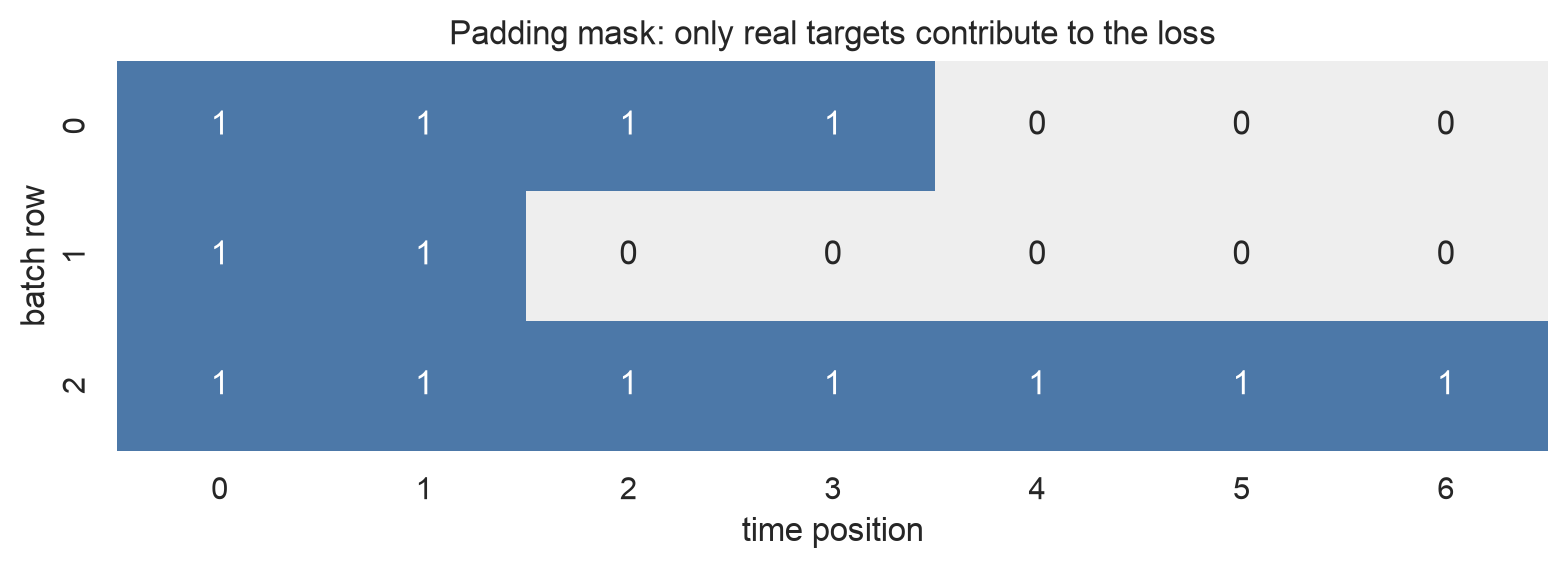

In [5]:
fig, ax = plt.subplots(figsize=(8,3))
sns.heatmap(valid_mask, annot=True, cbar=False, cmap=["#eeeeee", "#4c78a8"], ax=ax)
ax.set(xlabel="time position", ylabel="batch row", title="Padding mask: only real targets contribute to the loss")
plt.tight_layout(); plt.show()

## Why tokenization is part of the model

The vocabulary is not a harmless preprocessing detail. A character vocabulary gives the model short, predictable steps but many time positions. Word tokens shorten the sequence but make the vocabulary much larger and create an unknown-word problem. Subword tokenization sits between these extremes: frequent pieces get their own IDs, while rare words can be decomposed into reusable pieces. The model therefore learns over the representation chosen by the tokenizer.

## Reading the batch axes

For a next-token batch, `inputs[b, t]` is the token at time `t` in example `b`, and `targets[b, t]` is the token that should follow it. The model returns logits with shape `(batch, time, vocabulary)`. A padding mask is broadcast over the first two axes when the loss is reduced. Keeping these shapes explicit prevents a common error: treating a sequence batch as a flat list and losing which target belongs to which context.

## What this notebook establishes

Encoding, padding, and masking are three separate operations. Encoding chooses IDs; padding changes storage shape; masking decides which positions count as evidence. The next notebook removes the tokenizer abstraction temporarily and derives the attention weights that will later operate over the time axis.

## Takeaway

Tokenization determines the sequence length and the units the model can reuse. Batching adds a second axis, and padding requires a mask. The next notebook uses a tiny sequence to derive the attention operation that routes information between those positions.